In [24]:
# note running with stlearn_env environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
from pathlib import Path
from collections.abc import Mapping
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
from pycirclize import Circos

In [101]:
import utils.paths as d
import utils.functions as f

## Hyperparameters
Chord plots show the top `N_TOP` ligand-receptor pairs sent from `LIGANDS_prod` to `RECEPTORS_prod`.
The same LR pairs, colours and sector order are used in every plot, so WT and Mut are directly comparable.

In [69]:
N_TOP = 10
LIGANDS_prod = ["Craniofacial developmental mesenchymal cells"]          # sender cell types (ligand producers)
RECEPTORS_prod = ["ECM producing mesenchymal cells"]        # receiver cell types (receptor producers)

USE_LABEL = "annotation_safe"           # matches adata.uns[f"per_lr_cci_{USE_LABEL}"]
P_CUTOFF = 0.05
GROUP_A, GROUP_B = "wt", "mut"          # contrast: delta = mean(GROUP_A) - mean(GROUP_B)
RANK_BY = "delta"                        # "mean": top pairs by mean frac over all samples; "delta": by |WT - Mut|

FIG_DIR = d.project_root / "figures" / "08_stlearn" / "chord"
FIG_DIR.mkdir(parents=True, exist_ok=True)

Available: ['Basal epithelial cells', 'Chondrocytes', 'Craniofacial developmental mesenchymal cells', 'Dental epithelial cells', 'Dental follicle cells', 'Dental follicle mesenchymal cells', 'Differentiated epithelial cells', 'ECM producing mesenchymal cells', 'Early osteoblasts', 'Endothelial cells', 'Keratinized epithelial cells', 'Lymphatic endothelial cells', 'Macrophages', 'Mast cells', 'Matrix-secreting osteoblast lineage cells', 'Mesenchymal progenitor cells', 'Mut-specific dental cells', 'Myogenic progenitor', 'Neural crest', 'Oral epithelial cells', 'Osteoclasts', 'Osteogenic progenitors', 'Outer fibroperiosteal cells', 'Pre-osteocytes_diff. osteoblast lineage cells', 'Signaling epithelial cells', 'Skeletal muscle', 'Vascular smooth muscle cells', 'perivascular smooth muscle cells']

In [54]:
grids["Wt_1"].obs[USE_LABEL].value_counts()

annotation_safe
Craniofacial developmental mesenchymal cells     2983
ECM producing mesenchymal cells                  1729
Matrix-secreting osteoblast lineage cells        1462
Skeletal muscle                                  1364
Endothelial cells                                1363
Mesenchymal progenitor cells                     1283
Osteogenic progenitors                           1122
Dental epithelial cells                          1043
Myogenic progenitor                               961
Early osteoblasts                                 765
Dental papilla cells                              759
Signaling epithelial cells                        737
Pre-osteocytes_diff. osteoblast lineage cells     732
Basal epithelial cells                            633
Keratinized epithelial cells                      622
Differentiated epithelial cells                   567
Macrophages                                       504
Dental follicle cells                             430
Dental folli

In [38]:
sample_order = ["Wt_1", "Wt_2", "Wt_3", "Wt_4", "Mut_1", "Mut_2", "Mut_3", "Mut_4"]
sample_groups = {"Wt_1": "wt", "Wt_2": "wt", "Wt_3": "wt", "Wt_4": "wt",
                 "Mut_1": "mut", "Mut_2": "mut", "Mut_3": "mut", "Mut_4": "mut"}

grid_paths = {
    "Wt_1": d.stlearn_dir / "cci" / "wt_1_lit_grid250_cci.h5ad",
    "Wt_2": d.stlearn_dir / "cci" / "wt_2_lit_grid250_cci.h5ad",
    "Wt_3": d.stlearn_dir / "cci" / "wt_3_lit_grid250_cci.h5ad",
    #"Wt_4": d.stlearn_dir / "cci" / "wt_4_lit_grid250_cci.h5ad",
    "Mut_1": d.stlearn_dir / "cci" / "mut_1_lit_grid250_cci.h5ad",
    "Mut_2": d.stlearn_dir / "cci" / "mut_2_lit_grid250_cci.h5ad",
    "Mut_3": d.stlearn_dir / "cci" / "mut_3_lit_grid250_cci.h5ad",
    "Mut_4": d.stlearn_dir / "cci" / "mut_4_lit_grid250_cci.h5ad",
}
sample_order = [s for s in sample_order if s in grid_paths]

grids = {name: sc.read_h5ad(path) for name, path in grid_paths.items()}

In [63]:
def _require_uns(adata, key):
    if key not in adata.uns:
        raise KeyError(
            f"'{key}' not found in adata.uns. Run "
            f"st.tl.cci.run_cci(adata, ...) with n_perms > 0 first."
        )
    return adata.uns[key]


def rank_lr_pairs(adata, ligand_types, receptor_types, use_label=USE_LABEL, p_cutoff=P_CUTOFF):
    """Rank LR pairs by significant interactions sent from ligand_types (rows) to receptor_types (columns).

    frac_sig = significant interactions in the ligand->receptor block / all significant
    interactions in the sample (all LR pairs, all cell types), so it is comparable across samples.

    Cell types absent from this sample (no cells -> not in the CCI matrix) contribute 0;
    returns an empty table if no ligand or no receptor cell type is present.
    """
    per_lr_sig = _require_uns(adata, f"per_lr_cci_{use_label}")
    per_lr_p = _require_uns(adata, f"per_lr_cci_pvals_{use_label}")
    columns = ["lr", "ligand", "receptor", "sig_count", "neg_log10_p", "frac_sig"]

    celltypes = pd.DataFrame(next(iter(per_lr_sig.values()))).index
    missing = [ct for ct in list(ligand_types) + list(receptor_types) if ct not in celltypes]
    if missing:
        print(f"[rank_lr_pairs] not in this sample (counted as 0): {missing}")
    ligand_types = [ct for ct in ligand_types if ct in celltypes]
    receptor_types = [ct for ct in receptor_types if ct in celltypes]
    if not ligand_types or not receptor_types:
        return pd.DataFrame(columns=columns).set_index("lr")

    sample_total_sig = float(sum(pd.DataFrame(m).to_numpy().sum() for m in per_lr_sig.values()))
    if sample_total_sig == 0:
        raise ValueError("No significant ligand-receptor pairs found.")

    rows = []
    for lr, sig_mat in per_lr_sig.items():
        block_sig = pd.DataFrame(sig_mat).loc[ligand_types, receptor_types].to_numpy(dtype=float)
        block_p = pd.DataFrame(per_lr_p[lr]).loc[ligand_types, receptor_types].to_numpy(dtype=float)
        sig_count = float(block_sig.sum())
        if sig_count <= 0:
            continue
        sig_cells = block_p < p_cutoff
        neg_log10_p = (
            float(np.mean(-np.log10(np.clip(block_p[sig_cells], 1e-4, None))))
            if sig_cells.any()
            else 0.0
        )
        lig, rec = lr.split("_", 1)
        rows.append((lr, lig, rec, sig_count, neg_log10_p, sig_count / sample_total_sig))

    out = pd.DataFrame(rows, columns=columns).set_index("lr")
    return out.sort_values(["frac_sig", "neg_log10_p"], ascending=False)

In [64]:
def contrast_lr_pairs(adatas, groups, ligand_types, receptor_types,
                      group_a=GROUP_A, group_b=GROUP_B, use_label=USE_LABEL, p_cutoff=P_CUTOFF):
    """Per-sample frac_sig (LR x sample) plus group means and delta = mean_a - mean_b.

    Pairs absent in a sample get 0. Sorted by |delta| desc.
    """
    # A typo would otherwise silently give 0 everywhere: require each cell type in >=1 sample
    present = set()
    for ad in adatas.values():
        present |= set(pd.DataFrame(next(iter(ad.uns[f"per_lr_cci_{use_label}"].values()))).index)
    unknown = [ct for ct in list(ligand_types) + list(receptor_types) if ct not in present]
    if unknown:
        raise ValueError(f"Cell type(s) {unknown} not found in any sample. Available: {sorted(present)}")

    per_sample = {}
    for name, ad in adatas.items():
        print(name)
        r = rank_lr_pairs(ad, ligand_types, receptor_types, use_label=use_label, p_cutoff=p_cutoff)
        per_sample[name] = r["frac_sig"].astype(float)

    frac = pd.DataFrame(per_sample).reindex(columns=list(adatas)).fillna(0.0)
    if frac.empty:
        raise ValueError(f"No significant interactions {ligand_types} -> {receptor_types} in any sample.")
    a_cols = [n for n in frac.columns if groups.get(n) == group_a]
    b_cols = [n for n in frac.columns if groups.get(n) == group_b]
    if not a_cols or not b_cols:
        raise ValueError(f"Need >=1 sample per group. Found {group_a}: {a_cols}, {group_b}: {b_cols}.")

    out = frac.copy()
    out[f"frac_{group_a}"] = frac[a_cols].mean(axis=1)
    out[f"frac_{group_b}"] = frac[b_cols].mean(axis=1)
    out["frac_mean"] = frac.mean(axis=1)
    out["delta"] = out[f"frac_{group_a}"] - out[f"frac_{group_b}"]
    out["ligand"] = [i.split("_", 1)[0] for i in out.index]
    out["receptor"] = [i.split("_", 1)[1] for i in out.index]
    return out.reindex(out["delta"].abs().sort_values(ascending=False).index)

In [65]:
def select_top_pairs(contrast, n_top=N_TOP, rank_by=RANK_BY):
    key = contrast["frac_mean"] if rank_by == "mean" else contrast["delta"].abs()
    return key.sort_values(ascending=False).head(n_top).index.tolist()


def lr_palette(lr_pairs, cmap="tab20"):
    cyc = plt.get_cmap(cmap).colors
    return {lr: to_hex(cyc[k % len(cyc)]) for k, lr in enumerate(lr_pairs)}


PAD_L, PAD_R = " ", "  "  # invisible sectors that fill the circle up to scale_total


def plot_lr_chord(frac, lr_pairs, palette, ax=None, title=None, scale_total=None, link_alpha=0.8,
                  ligand_color="#bdbdbd", receptor_color="#636363"):
    """Chord diagram of ligand genes (L) -> receptor genes (R); ribbon width = frac_sig.

    frac : Series indexed by LR pair (e.g. one sample's or one group's frac_sig).
    lr_pairs / palette : fixed across plots, so colours and sector order match.
    scale_total : pycirclize always fills the full circle; pass the same value (e.g. the
        largest panel total) to every plot so arc lengths are on a common scale and the
        unused part of the circle stays empty.
    """
    lig_order = list(dict.fromkeys(lr.split("_", 1)[0] + " (L)" for lr in lr_pairs))
    rec_order = list(dict.fromkeys(lr.split("_", 1)[1] + " (R)" for lr in lr_pairs))
    matrix = pd.DataFrame(0.0, index=lig_order, columns=rec_order)
    for lr in lr_pairs:
        lig, rec = lr.split("_", 1)
        matrix.loc[f"{lig} (L)", f"{rec} (R)"] += float(frac.get(lr, 0.0))

    # pycirclize cannot draw zero-size sectors: drop genes without any interaction here
    matrix = matrix.loc[matrix.sum(axis=1) > 0, matrix.sum(axis=0) > 0]
    if matrix.empty:
        ax.set_axis_off()
        ax.set_title(f"{title}\n(no significant interactions)" if title else "no significant interactions")
        return None

    link_cmap = [
        (f"{lr.split('_', 1)[0]} (L)", f"{lr.split('_', 1)[1]} (R)", palette[lr])
        for lr in lr_pairs if frac.get(lr, 0.0) > 0
    ]
    sector_cmap = {s: ligand_color for s in matrix.index} | {s: receptor_color for s in matrix.columns}
    order = [s for s in lig_order + rec_order if s in matrix.index or s in matrix.columns]

    # pad both halves (L and R) so every panel spans the same total
    pad = (scale_total - matrix.to_numpy().sum()) if scale_total else 0
    if pad > 1e-12:
        matrix.loc[PAD_L] = 0.0
        matrix[PAD_R] = 0.0
        matrix.loc[PAD_L, PAD_R] = pad
        matrix = matrix.fillna(0.0)
        sector_cmap |= {PAD_L: "none", PAD_R: "none"}
        order += [PAD_L, PAD_R]

    circos = Circos.chord_diagram(
        matrix,
        space=4,
        cmap=sector_cmap,
        link_cmap=link_cmap,
        order=order,
        label_kws={"size": 8, "r": 106, "orientation": "vertical"},
        link_kws={"direction": 1, "ec": "#202020", "lw": 0.2, "alpha": link_alpha},
        link_kws_handler=lambda f, t: {"alpha": 0, "lw": 0} if f == PAD_L else None,
    )
    # hide the padding sectors' outline
    for sector in circos.sectors:
        if sector.name in (PAD_L, PAD_R):
            for track in sector.tracks:
                for patch in track._patches:
                    patch.set_edgecolor("none")
    circos.plotfig(ax=ax)
    if title:
        ax.set_title(title, fontsize=12, pad=55)
    return circos


def add_lr_legend(fig, lr_pairs, palette, ncol=1):
    handles = [Patch(facecolor=palette[lr], edgecolor="#202020", linewidth=0.3, label=lr.replace("_", "-"))
               for lr in lr_pairs]
    fig.legend(handles=handles, title="Ligand-receptor pair", loc="center left",
               bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8.5, title_fontsize=9.5, ncol=ncol)


def chord_panel(frac_by_panel, lr_pairs, palette, suptitle=None, ncols=4, panel_size=4.5, save=None):
    """One chord plot per column of frac_by_panel (DataFrame LR x panel).

    Shared LR pairs, colours, sector order and scale, so panels are directly comparable.
    """
    names = list(frac_by_panel.columns)
    nrows = int(np.ceil(len(names) / ncols))
    ncols = min(ncols, len(names))
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_size * ncols, panel_size * nrows),
                             subplot_kw={"projection": "polar"}, squeeze=False)
    scale_total = frac_by_panel.loc[lr_pairs].sum().max()  # common scale: the busiest panel fills the circle
    for ax, name in zip(axes.flat, names):
        plot_lr_chord(frac_by_panel[name], lr_pairs, palette, ax=ax, title=name, scale_total=scale_total)
    for ax in axes.flat[len(names):]:
        ax.set_axis_off()
    add_lr_legend(fig, lr_pairs, palette)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.05)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300, bbox_inches="tight")
    return fig

In [70]:
contrast = contrast_lr_pairs(grids, sample_groups, LIGANDS_prod, RECEPTORS_prod)
top_pairs = select_top_pairs(contrast)
palette = lr_palette(top_pairs)

display(contrast.loc[top_pairs, ["ligand", "receptor", f"frac_{GROUP_A}", f"frac_{GROUP_B}", "delta"] + sample_order])

Wt_1
Wt_2
Wt_3
Mut_1
Mut_2
Mut_3
Mut_4


,ligand,receptor,frac_wt,frac_mut,delta,Wt_1,Wt_2,Wt_3,Mut_1,Mut_2,Mut_3,Mut_4
lr,,,,,,,,,,,,
Col1a1_Cd44,Col1a1,Cd44,0.000207,0.000093,0.000114,0.000112,0.000221,0.000287,0.0,0.000175,0.000105,0.000092
Col1a2_Cd44,Col1a2,Cd44,0.000235,0.000069,0.000166,0.000122,0.000280,0.000303,0.0,0.000170,0.000000,0.000105
Fgf18_Fgfr1,Fgf18,Fgfr1,0.000221,0.000000,0.000221,0.000212,0.000197,0.000254,0.0,0.000000,0.000000,0.000000
Slit2_Robo1,Slit2,Robo1,0.000181,0.000000,0.000181,0.000146,0.000103,0.000294,0.0,0.000000,0.000000,0.000000
Fn1_Cd44,Fn1,Cd44,0.000101,0.000047,0.000053,0.000000,0.000164,0.000138,0.0,0.000084,0.000058,0.000048
Col1a1_Ddr1,Col1a1,Ddr1,0.000130,0.000000,0.000130,0.000000,0.000092,0.000296,0.0,0.000000,0.000000,0.000000
Tnc_Egfr,Tnc,Egfr,0.000128,0.000000,0.000128,0.000124,0.000108,0.000151,0.0,0.000000,0.000000,0.000000
Tgfb3_Tgfbr3,Tgfb3,Tgfbr3,0.000079,0.000033,0.000046,0.000053,0.000000,0.000183,0.0,0.000132,0.000000,0.000000
Tnc_Itgav,Tnc,Itgav,0.000117,0.000000,0.000117,0.000130,0.000126,0.000096,0.0,0.000000,0.000000,0.000000


In [93]:
contrast.sort_values("delta", ascending=False).head(HOW_MANY_TO_PLOT)[["ligand", "receptor", f"frac_{GROUP_A}", f"frac_{GROUP_B}", "delta"] + sample_order]

,ligand,receptor,frac_wt,frac_mut,delta,Wt_1,Wt_2,Wt_3,Mut_1,Mut_2,Mut_3,Mut_4
lr,,,,,,,,,,,,
Fgf18_Fgfr1,Fgf18,Fgfr1,0.000221,0.000000,0.000221,0.000212,0.000197,0.000254,0.0,0.000000,0.000000,0.000000
Slit2_Robo1,Slit2,Robo1,0.000181,0.000000,0.000181,0.000146,0.000103,0.000294,0.0,0.000000,0.000000,0.000000
Col1a2_Cd44,Col1a2,Cd44,0.000235,0.000069,0.000166,0.000122,0.000280,0.000303,0.0,0.000170,0.000000,0.000105
Col1a1_Ddr1,Col1a1,Ddr1,0.000130,0.000000,0.000130,0.000000,0.000092,0.000296,0.0,0.000000,0.000000,0.000000
Tnc_Egfr,Tnc,Egfr,0.000128,0.000000,0.000128,0.000124,0.000108,0.000151,0.0,0.000000,0.000000,0.000000
Tnc_Itgav,Tnc,Itgav,0.000117,0.000000,0.000117,0.000130,0.000126,0.000096,0.0,0.000000,0.000000,0.000000
Col1a1_Cd44,Col1a1,Cd44,0.000207,0.000093,0.000114,0.000112,0.000221,0.000287,0.0,0.000175,0.000105,0.000092
Fn1_Itga8,Fn1,Itga8,0.000113,0.000000,0.000113,0.000000,0.000000,0.000339,0.0,0.000000,0.000000,0.000000
Slit2_Sdc1,Slit2,Sdc1,0.000111,0.000000,0.000111,0.000097,0.000000,0.000236,0.0,0.000000,0.000000,0.000000


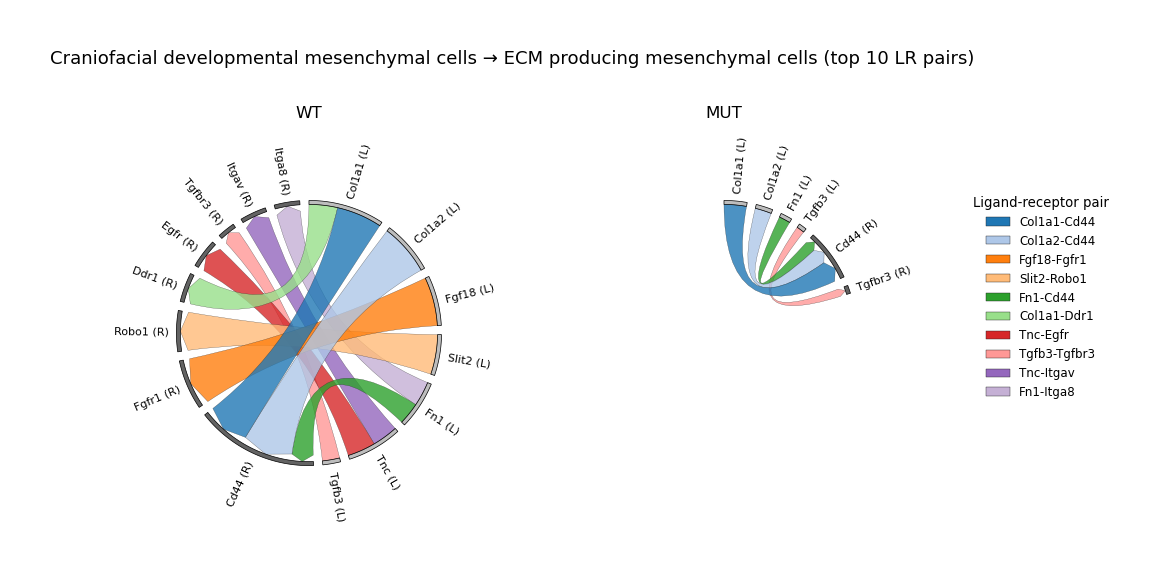

In [71]:
tag = f"{'+'.join(LIGANDS_prod)}_to_{'+'.join(RECEPTORS_prod)}_top{N_TOP}_{RANK_BY}".replace(" ", "-")
title = f"{', '.join(LIGANDS_prod)} → {', '.join(RECEPTORS_prod)} (top {N_TOP} LR pairs)"

# Group means (WT vs Mut)
fig = chord_panel(contrast[[f"frac_{GROUP_A}", f"frac_{GROUP_B}"]].rename(columns=lambda c: c.removeprefix("frac_").upper()),
                  top_pairs, palette, suptitle=title, ncols=2,
                  save=FIG_DIR / f"chord_groups_{tag}.png")
plt.show()

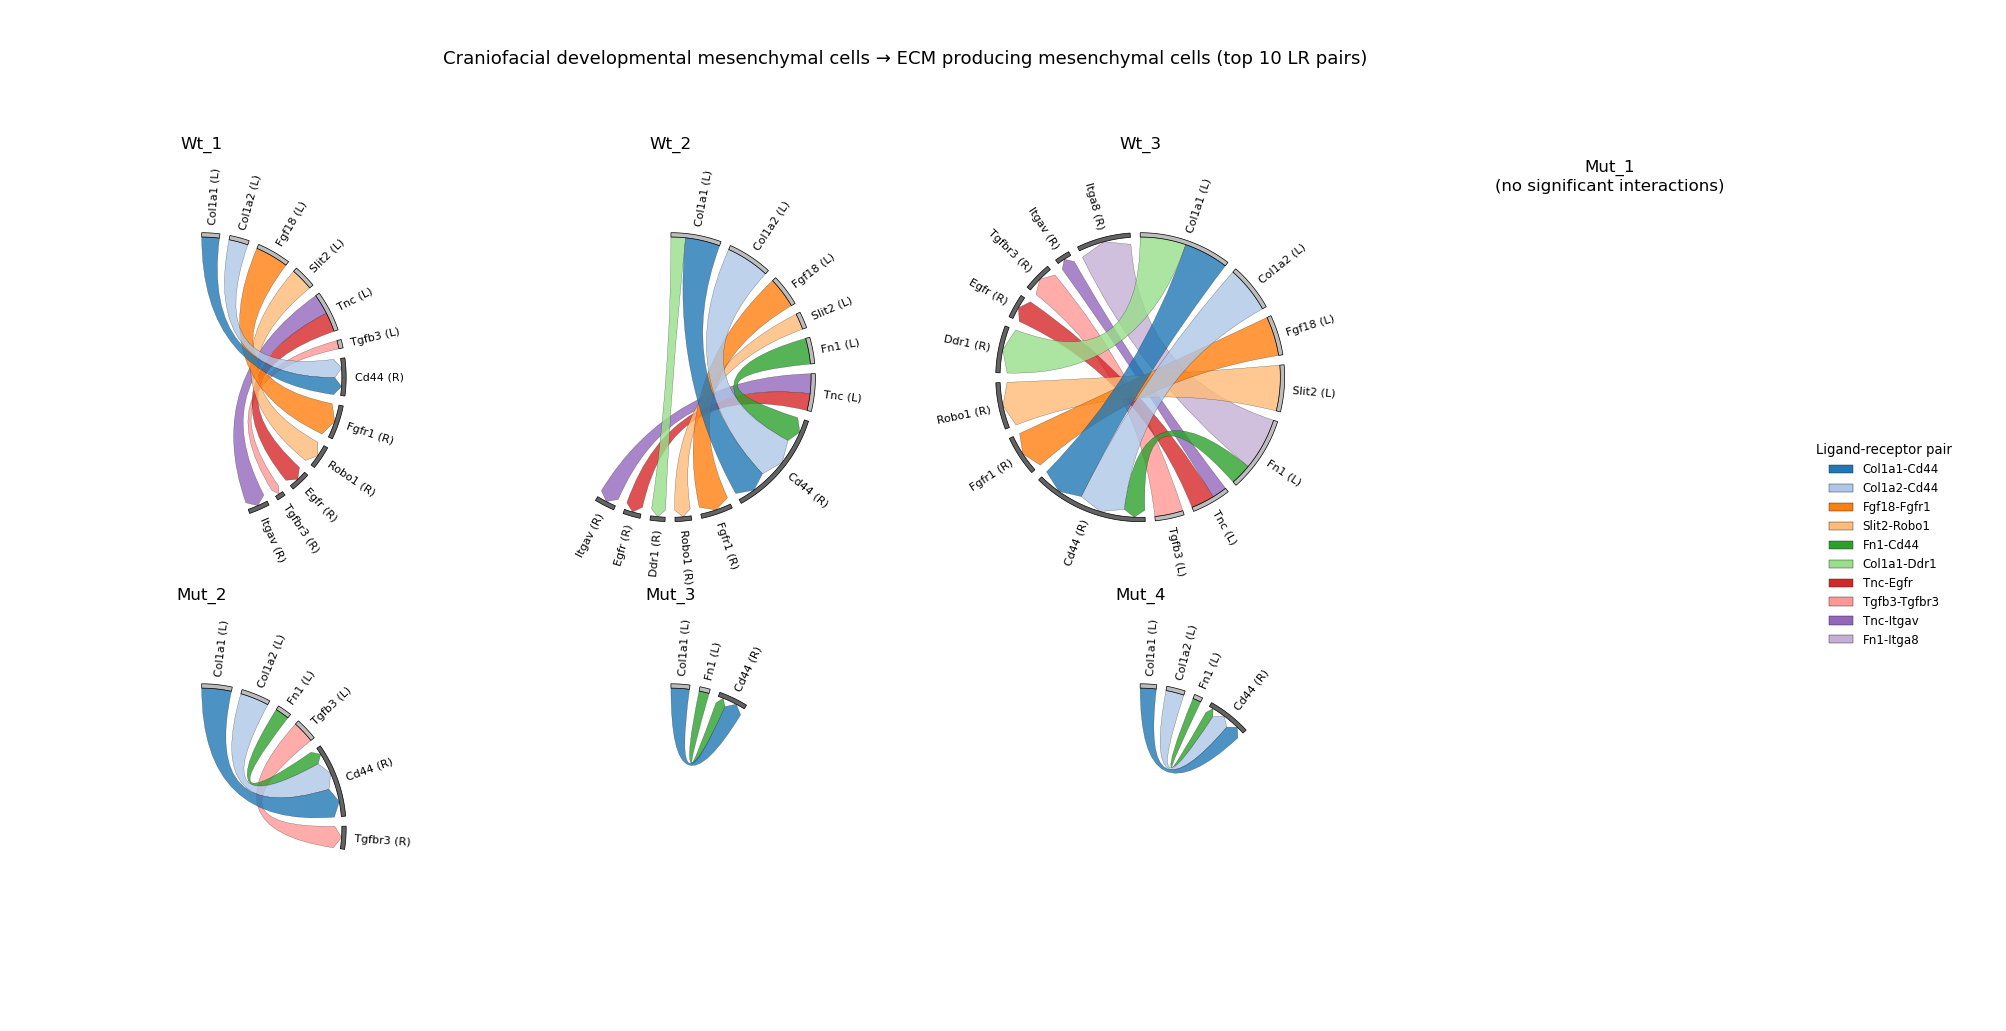

In [68]:
# Individual samples
fig = chord_panel(contrast[sample_order], top_pairs, palette, suptitle=title, ncols=4,
                  save=FIG_DIR / f"chord_samples_{tag}.png")
plt.show()

# Vizualizace na spatial coordinates
- `TRANSFORM` = {"flip": "y", "rotate": 0} # flip "x" = mirror left-right, "y" = mirror up-down; rotate = degrees counter-clockwise (after the flip)
- `SAMPLE` = "Wt_3"
- `LTO_PLOT` = "Fgf18_Fgfr1"
- `HOW_MANY_TO_PLOT`

In [72]:
import stlearn as st

In [94]:
SAMPLE = "Wt_3"
LR_TO_PLOT = "Fgf18_Fgfr1"

In [120]:
# flip "x" = mirror left-right, "y" = mirror up-down; rotate = degrees counter-clockwise (after the flip)
TRANSFORM = {"flip": "y", "rotate": 180}

g = grids[SAMPLE]
g.obs["sample"] = SAMPLE                       # orient_samples selects spots by obs["sample"]
f.orient_samples(g, transforms={SAMPLE: TRANSFORM})
# stLearn plots read obs imagecol/imagerow, not obsm["spatial"]
g.obs["imagecol"] = g.obsm["spatial"][:, 0]
g.obs["imagerow"] = g.obsm["spatial"][:, 1]

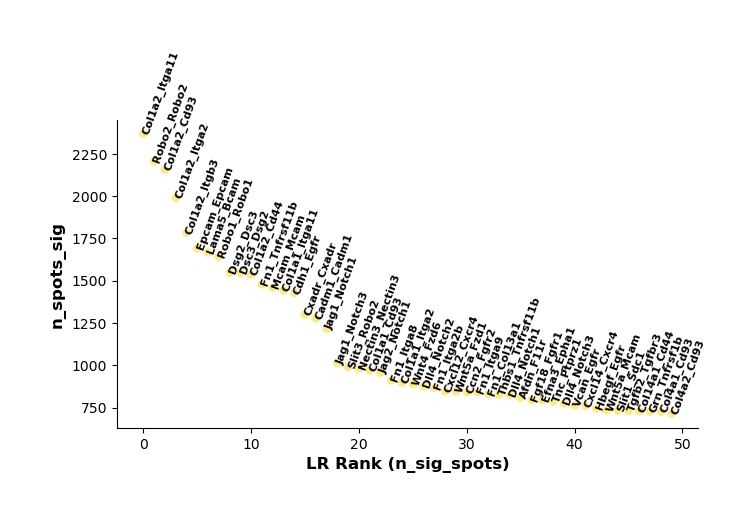

In [125]:
st.pl.lr_summary(g)

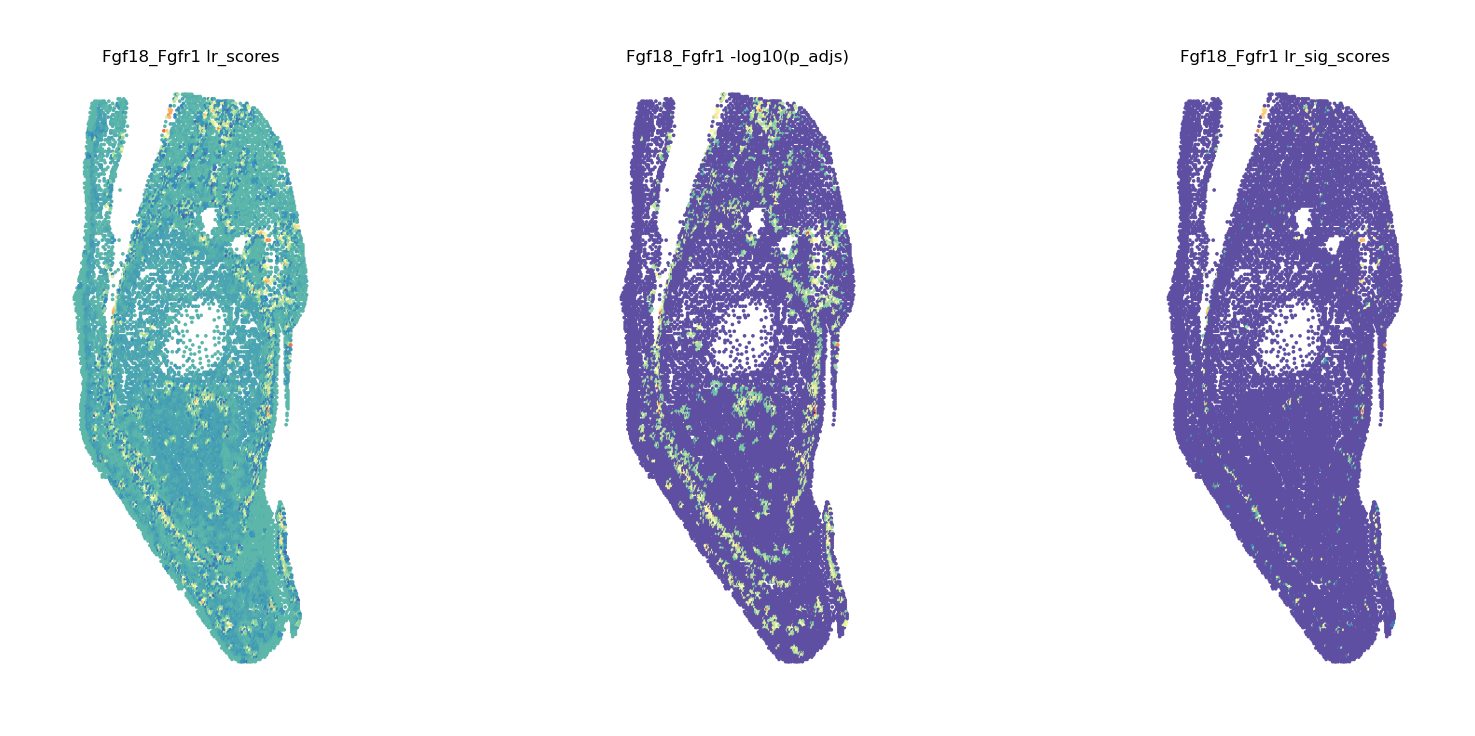

In [96]:
stats = ['lr_scores', '-log10(p_adjs)', 'lr_sig_scores']

fig, axes = plt.subplots(ncols=len(stats), figsize=(20, 8))
for i, stat in enumerate(stats):
    st.pl.lr_result_plot(grids[SAMPLE], use_result=stat, use_lr=LR_TO_PLOT, show_color_bar=False, ax=axes[i], show_image=False)
    axes[i].set_aspect('equal')
    axes[i].set_title(f'{LR_TO_PLOT} {stat}')

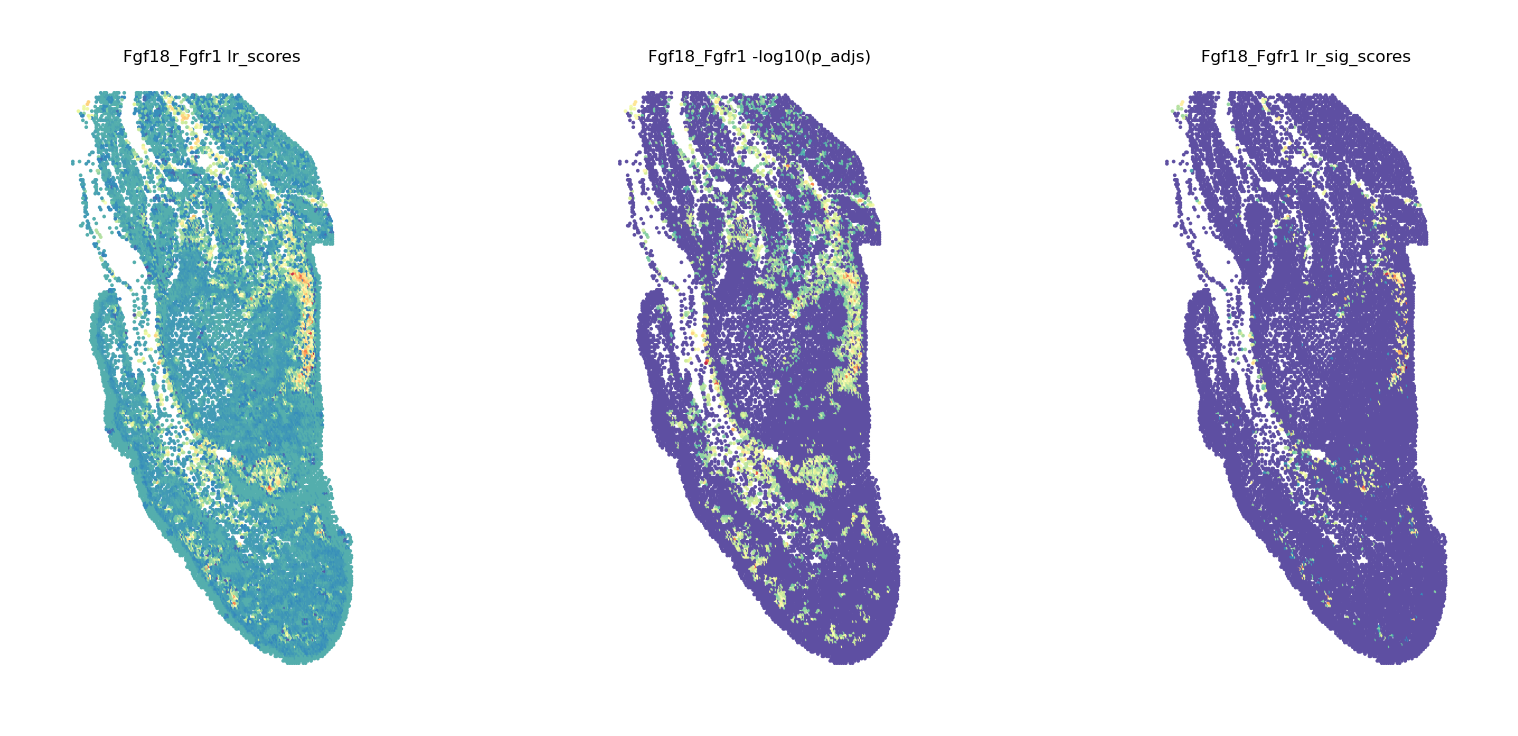

In [121]:
stats = ['lr_scores', '-log10(p_adjs)', 'lr_sig_scores']
SAMPLE = "Mut_3"
fig, axes = plt.subplots(ncols=len(stats), figsize=(20, 8))
for i, stat in enumerate(stats):
    st.pl.lr_result_plot(grids[SAMPLE], use_result=stat, use_lr=LR_TO_PLOT, show_color_bar=False, ax=axes[i], show_image=False)
    axes[i].set_aspect('equal')
    axes[i].set_title(f'{LR_TO_PLOT} {stat}')

In [91]:
HOW_MANY_TO_PLOT = 15
grids[SAMPLE].uns["lr_summary"].sort_values(ascending=False, by="n_spots_sig_pval").head(HOW_MANY_TO_PLOT)

,n_spots,n_spots_sig,n_spots_sig_pval,n_cci_sig_annotation_safe,n-spot_cci_annotation_safe,n-spot_cci_sig_annotation_safe
Col1a1_Itga11,4500,2575,4478,68.0,7433.0,6356.0
Col1a2_Itga11,4478,2517,4420,66.0,7563.0,6388.0
Col1a2_Cd93,4282,2388,4282,112.0,6585.0,5750.0
Col1a1_Cd93,4225,2450,4225,111.0,6448.0,5623.0
Col1a1_Itga2,3888,1955,3829,95.0,5138.0,4315.0
Col1a2_Itga2,3920,1836,3795,96.0,5344.0,4488.0
Col1a1_Cd36,3567,1408,3440,79.0,3808.0,3146.0
Col1a1_Cd44,3937,1307,3421,89.0,6095.0,5138.0
Col1a2_Itgb3,3331,1917,3331,106.0,4727.0,3746.0
Col1a1_Ddr1,3788,1152,3143,73.0,6070.0,4765.0
